In [4]:
# Gerekli kütüphaneleri içe aktarıyoruz
import pandas as pd
import numpy as np

# 1. Veri Setini Yükleme
csv_path = 'Data_Entry_2017.csv'
df = pd.read_csv(csv_path)

# --- YENİ ADIM: GERÇEK SÜTUN İSİMLERİNİ KONTROL EDELİM ---
# Bu komut, CSV dosyasındaki sütunların BİREBİR aynısını bize listeleyecektir.
print("--- Dosyadaki Gerçek Sütun İsimleri ---")
print(df.columns.tolist())
print("\n")
# -----------------------------------------------------------

# 2. Tüm Benzersiz Etiketleri Bulma
all_labels = []
for labels in df['Finding Labels']:
    all_labels.extend(labels.split('|'))

unique_labels = np.unique([label for label in all_labels if label != 'No Finding'])

print(f"--- Toplam {len(unique_labels)} adet benzersiz hastalık etiketi bulundu ---")
print(unique_labels)
print("\n")


# 3. Her Hastalık İçin Ayrı Bir Sütun Oluşturma
for label in unique_labels:
    df[label] = df['Finding Labels'].apply(lambda x: 1 if label in x else 0)

# 4. Gereksiz Sütunları Silme (DÜZELTİLMİŞ KISIM)
# Hata veren sütun isimlerini, dosyadaki gerçek isimlere göre güncelledik.
# Genellikle isimler bu şekildedir.
columns_to_drop = [
    'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 
    'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 
    'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11'
]

# Sadece var olan sütunları silmeye çalışmak için `errors='ignore'` eklemek iyi bir pratiktir.
# Bu sayede listede olmayan bir sütun olursa bile kod hata vermeden devam eder.
df_processed = df.drop(columns=columns_to_drop, errors='ignore')


# 5. İşlenmiş Veriye Son Bakış
print("--- Veri Setinin İşlenmiş Hali (ilk 5 satır) ---")
pd.set_option('display.max_columns', None)
print(df_processed.head())

--- Dosyadaki Gerçek Sütun İsimleri ---
['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImageWidth', 'OriginalImageHeight', 'OriginalImagePixelSpacing_x', 'OriginalImagePixelSpacing_y']


--- Toplam 14 adet benzersiz hastalık etiketi bulundu ---
['Atelectasis' 'Cardiomegaly' 'Consolidation' 'Edema' 'Effusion'
 'Emphysema' 'Fibrosis' 'Hernia' 'Infiltration' 'Mass' 'Nodule'
 'Pleural_Thickening' 'Pneumonia' 'Pneumothorax']


--- Veri Setinin İşlenmiş Hali (ilk 5 satır) ---
        Image Index  OriginalImageWidth  OriginalImageHeight  \
0  00000001_000.png                2682                 2749   
1  00000001_001.png                2894                 2729   
2  00000001_002.png                2500                 2048   
3  00000002_000.png                2500                 2048   
4  00000003_000.png                2582                 2991   

   OriginalImagePixelSpacing_x  OriginalImagePixelSpacing_y  Atel

In [5]:
import os 
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --- 1. SADECE BİLGİSAYARDAKİ MEVCUT RESİMLERİ KULLAN ---

image_dir = 'images/' 

# 'images' klasöründeki tüm resim dosyalarının isimlerini bir liste olarak alalım.
available_images = os.listdir(image_dir)

# Orijinal df_processed tablomuzu, sadece 'Image Index' sütunu 
# mevcut resimler listesinde olanlarla filtreleyelim.
df_filtered = df_processed[df_processed['Image Index'].isin(available_images)]

print(f"Toplam {len(df_processed)} resim listesinden,")
print(f"Bilgisayarında bulunan {len(df_filtered)} resim ile devam ediliyor.")
print("\n")


# --- 2. Filtrelenmiş Veri Setini Eğitim, Doğrulama ve Test Olarak Ayırma ---

train_df, test_val_df = train_test_split(
    df_filtered,
    test_size=0.2,
    random_state=42
)

valid_df, test_df = train_test_split(
    test_val_df, 
    test_size=0.5,
    random_state=42
)

print(f"Eğitim seti boyutu: {len(train_df)} görüntü")
print(f"Doğrulama seti boyutu: {len(valid_df)} görüntü")
print(f"Test seti boyutu: {len(test_df)} görüntü")
print("\n")


# --- 3. Veri Üreteçlerini (Data Generators) Ayarlama ---

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
labels = unique_labels.tolist()

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

print("--- Eğitim Veri Üreteci Oluşturuluyor ---")
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=image_dir,
    x_col='Image Index',
    y_col=labels,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='raw',
    seed=42
)

print("\n--- Doğrulama Veri Üreteci Oluşturuluyor ---")
validation_generator = val_test_datagen.flow_from_dataframe(
    dataframe=valid_df,
    directory=image_dir,
    x_col='Image Index',
    y_col=labels,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='raw',
    shuffle=False
)

print("\n--- Test Veri Üreteci Oluşturuluyor ---")
test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=image_dir,
    x_col='Image Index',
    y_col=labels,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='raw',
    shuffle=False
)

Toplam 112120 resim listesinden,
Bilgisayarında bulunan 54999 resim ile devam ediliyor.


Eğitim seti boyutu: 43999 görüntü
Doğrulama seti boyutu: 5500 görüntü
Test seti boyutu: 5500 görüntü


--- Eğitim Veri Üreteci Oluşturuluyor ---
Found 43999 validated image filenames.

--- Doğrulama Veri Üreteci Oluşturuluyor ---
Found 5500 validated image filenames.

--- Test Veri Üreteci Oluşturuluyor ---
Found 5500 validated image filenames.


In [6]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --- 1. Veri Setini Eğitim, Doğrulama ve Test Olarak Ayırma (TÜM VERİ İÇİN GÜNCELLENDİ) ---

# DİKKAT: Filtreleme adımları (os.listdir, df_filtered vb.) tamamen kaldırıldı.
# Artık doğrudan, 112,000 resmin bilgisini içeren ana veri listemiz olan df_processed'i kullanıyoruz.
train_df, test_val_df = train_test_split(
    df_processed, # <--- EN ÖNEMLİ DEĞİŞİKLİK BURADA
    test_size=0.2,
    random_state=42
)

valid_df, test_df = train_test_split(
    test_val_df, 
    test_size=0.5,
    random_state=42
)

print("--- Tüm Veri Seti Boyutları ---")
print(f"Eğitim seti boyutu: {len(train_df)} görüntü")
print(f"Doğrulama seti boyutu: {len(valid_df)} görüntü")
print(f"Test seti boyutu: {len(test_df)} görüntü")
print("\n")


# --- 2. Veri Üreteçlerini (Data Generators) Ayarlama (BU KISIMDA DEĞİŞİKLİK YOK) ---
# Bu kısım aynı kalıyor, çünkü yukarıda oluşturulan yeni ve büyük train_df, valid_df 
# ve test_df'i otomatik olarak kullanacak.

image_dir = 'images/' 
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
labels = unique_labels.tolist()

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

print("--- Eğitim Veri Üreteci Oluşturuluyor ---")
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=image_dir,
    x_col='Image Index',
    y_col=labels,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='raw',
    seed=42
)

print("\n--- Doğrulama Veri Üreteci Oluşturuluyor ---")
validation_generator = val_test_datagen.flow_from_dataframe(
    dataframe=valid_df,
    directory=image_dir,
    x_col='Image Index',
    y_col=labels,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='raw',
    shuffle=False
)

print("\n--- Test Veri Üreteci Oluşturuluyor ---")
test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=image_dir,
    x_col='Image Index',
    y_col=labels,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='raw',
    shuffle=False
)

--- Tüm Veri Seti Boyutları ---
Eğitim seti boyutu: 89696 görüntü
Doğrulama seti boyutu: 11212 görüntü
Test seti boyutu: 11212 görüntü


--- Eğitim Veri Üreteci Oluşturuluyor ---
Found 43881 validated image filenames.

--- Doğrulama Veri Üreteci Oluşturuluyor ---
Found 5579 validated image filenames.

--- Test Veri Üreteci Oluşturuluyor ---
Found 5539 validated image filenames.


/opt/anaconda3/envs/pneumonia_env/lib/python3.10/site-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 45815 invalid image filename(s) in x_col="Image Index". These filename(s) will be ignored.
  warnings.warn(
/opt/anaconda3/envs/pneumonia_env/lib/python3.10/site-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 5633 invalid image filename(s) in x_col="Image Index". These filename(s) will be ignored.
  warnings.warn(
/opt/anaconda3/envs/pneumonia_env/lib/python3.10/site-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 5673 invalid image filename(s) in x_col="Image Index". These filename(s) will be ignored.
  warnings.warn(


In [7]:
# Gerekli kütüphaneleri ve modelleri TensorFlow/Keras'tan içe aktarıyoruz
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC

# --- 1. Önceden Eğitilmiş Modeli Yükleme ---

# DenseNet121 modelini ImageNet veri seti üzerinde eğitilmiş ağırlıklarıyla yüklüyoruz.
# 'include_top=False' diyerek, modelin sonundaki orijinal sınıflandırma katmanını atıyoruz.
# 'input_shape' ile de modelimize girecek resim boyutunu belirtiyoruz.
base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3) # (224, 224, 3)
)

# Transfer öğrenmenin ilk aşamasında, temel modelin ağırlıklarını donduruyoruz.
# Bu sayede, modelin daha önce öğrendiği değerli bilgiler (kenar, köşe, doku tanıma vb.)
# eğitim sırasında bozulmaz.
base_model.trainable = False


# --- 2. Kendi Modelimizi Oluşturma ---
# Temel modelin üzerine kendi katmanlarımızı ekleyeceğiz.

model = Sequential([
    base_model,  # Önceden eğitilmiş temel model
    
    # GlobalAveragePooling2D, temel modelden gelen çok boyutlu özellik haritalarını
    # tek boyutlu bir vektöre dönüştürür.
    GlobalAveragePooling2D(),
    
    # Overfitting'i (aşırı öğrenme/ezberleme) engellemek için bir Dropout katmanı ekliyoruz.
    # Bu katman, eğitim sırasında nöronların %20'sini rastgele kapatır.
    Dropout(0.2),
    
    # Bizim problemimize özel, 14 hastalığı tespit edecek olan son katman.
    # 14 nöron (her hastalık için bir tane) ve 'sigmoid' aktivasyon fonksiyonu kullanıyoruz.
    # Sigmoid, her bir hastalığın var olma olasılığını 0 ile 1 arasında bağımsız olarak hesaplar.
    Dense(len(labels), activation='sigmoid')
])


# --- 3. Modeli Derleme (Öğrenme Oranı Düşürülmüş Hali) ---
# Modeli, hangi kayıp fonksiyonu, optimize edici ve metriklerle eğiteceğimizi belirtiyoruz.

model.compile(
    optimizer=Adam(learning_rate=0.0001), # DEĞİŞİKLİK BURADA: 0.001 -> 0.0001
    loss='binary_crossentropy',
    metrics=[
        'binary_accuracy',
        AUC(name='auc')
    ]
)


# Modelimizin mimarisini bir özet olarak görelim.
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │        14,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,051,854 (26.90 MB)

 Trainable params: 14,350 (56.05 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [8]:
# Eğitimde kaç tur (epoch) döneceğimizi belirliyoruz.
# Epoch, modelin tüm eğitim verisini bir kez baştan sona görmesi demektir.
# Başlangıç için 10 iyi bir değerdir.
EPOCHS = 20

# Modelimizi eğitmeye başlıyoruz!
# Bu komut, eğitim sürecini başlatacak ve ilerlemeyi gösterecektir.
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator
)

print("\nEğitim Tamamlandı!")

/opt/anaconda3/envs/pneumonia_env/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
1372/1372 ━━━━━━━━━━━━━━━━━━━━ 683s 491ms/step - auc: 0.6794 - binary_accuracy: 0.9403 - loss: 0.2072 - val_auc: 0.7477 - val_binary_accuracy: 0.9499 - val_loss: 0.1798
Epoch 2/20
1372/1372 ━━━━━━━━━━━━━━━━━━━━ 680s 495ms/step - auc: 0.7364 - binary_accuracy: 0.9498 - loss: 0.1819 - val_auc: 0.7678 - val_binary_accuracy: 0.9499 - val_loss: 0.1749
Epoch 3/20
1105/1372 ━━━━━━━━━━━━━━━━━━━━ 1:57 441ms/step - auc: 0.7494 - binary_accuracy: 0.9502 - loss: 0.1780

KeyboardInterrupt: 

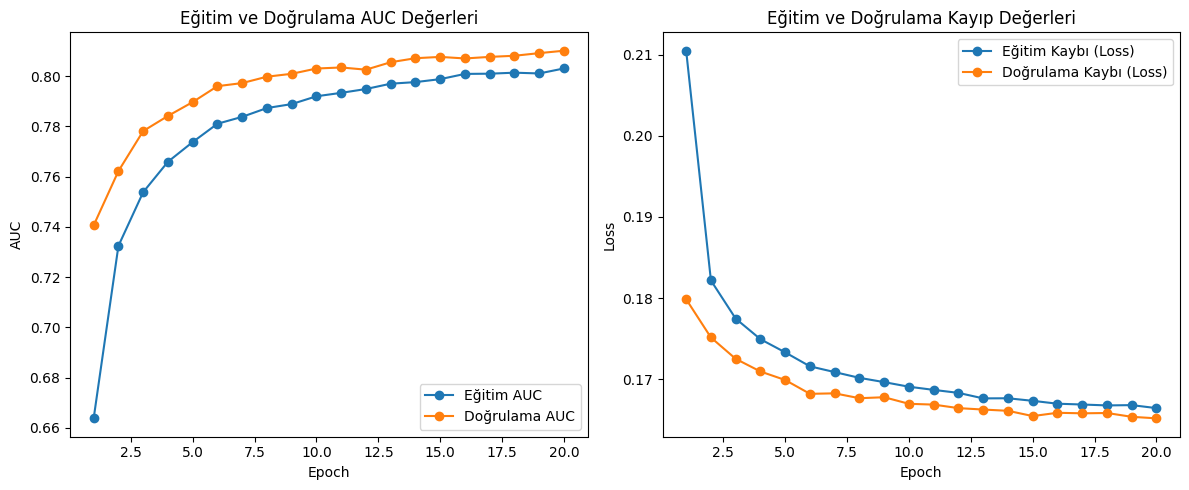

In [ ]:
import matplotlib.pyplot as plt

# Eğitim sürecinden gelen metrikleri değişkene atayalım
acc = history.history['auc']
val_acc = history.history['val_auc']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, EPOCHS + 1)

# Grafik için bir alan oluşturalım (2'li: biri AUC, biri Loss için)
plt.figure(figsize=(12, 5))

# AUC Grafiği
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, 'o-', label='Eğitim AUC')
plt.plot(epochs_range, val_acc, 'o-', label='Doğrulama AUC')
plt.title('Eğitim ve Doğrulama AUC Değerleri')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()

# Loss Grafiği
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, 'o-', label='Eğitim Kaybı (Loss)')
plt.plot(epochs_range, val_loss, 'o-', label='Doğrulama Kaybı (Loss)')
plt.title('Eğitim ve Doğrulama Kayıp Değerleri')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Grafikleri göster
plt.tight_layout()
plt.show()

In [ ]:
import sys

print("Test seti performansı değerlendiriliyor...")
# model.evaluate() bir liste döndürür: [loss, metric1, metric2, ...]
# Bizim compile() sıramız: [loss, 'binary_accuracy', AUC(name='auc')]
test_results = model.evaluate(test_generator)

print("\n--- Nihai Test Sonuçları (Düzeltilmiş Yazdırma) ---")

# test_results bir liste olduğu için, elemanlara index ile erişeceğiz
try:
    # test_results[0] her zaman 'loss' olur
    test_loss = test_results[0]
    # test_results[1] bizim 'binary_accuracy' metriğimiz
    test_accuracy = test_results[1]
    # test_results[2] bizim 'auc' metriğimiz
    test_auc = test_results[2]

    print(f"Test Seti Kayıp (Loss): {test_loss:.4f}")
    print(f"Test Seti Doğruluk (Accuracy): {test_accuracy:.4f}")
    print(f"Test Seti AUC: {test_auc:.4f}")

except IndexError:
    print("HATA: Sonuçlar beklenenden farklı bir formatta (eksik) döndü.")
    print("Dönen ham sonuç listesi:", test_results)
    print("Lütfen model.compile() fonksiyonunu kontrol edin.")
except Exception as e:
    print(f"Bir hata oluştu: {e}", file=sys.stderr)
    print("Dönen ham sonuç listesi:", test_results)

Test seti performansı değerlendiriliyor...
174/174 ━━━━━━━━━━━━━━━━━━━━ 60s 341ms/step - auc: 0.7899 - binary_accuracy: 0.9512 - loss: 0.1678

--- Nihai Test Sonuçları (Düzeltilmiş Yazdırma) ---
Test Seti Kayıp (Loss): 0.1678
Test Seti Doğruluk (Accuracy): 0.9512
Test Seti AUC: 0.7899


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

# Tahmin yapmak istediğin resmin yolunu belirt
# 'images' klasöründen herhangi bir resmin adını kopyalayıp yapıştırabilirsin.
# Örnek: 'images/00000013_005.png'
image_path = 'images/00001330_001.png'

try:
    # Resmi yükle ve modele uygun boyuta getir (224x224)
    img = image.load_img(image_path, target_size=IMAGE_SIZE)
    # Resmi bir diziye çevir
    img_array = image.img_to_array(img)
    # Piksel değerlerini 0-1 arasına ölçekle
    img_array /= 255.0
    # Modele tek bir resim göndereceğimiz için boyutunu genişlet (1, 224, 224, 3)
    img_array = np.expand_dims(img_array, axis=0)

    # Tahmini yap
    predictions = model.predict(img_array)

    # Sonuçları etiketlerle birleştirip gösterelim
    results = dict(zip(labels, predictions[0]))

    print(f"\n--- '{image_path}' İçin Tahmin Sonuçları ---")
    # Sonuçları olasılığa göre büyükten küçüğe sıralayalım
    sorted_results = sorted(results.items(), key=lambda item: item[1], reverse=True)
    
    for disease, probability in sorted_results:
        print(f"{disease}: {probability*100:.2f}%")

except FileNotFoundError:
    print(f"HATA: Belirtilen '{image_path}' dosyası bulunamadı. Lütfen dosya adını kontrol et.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step

--- 'images/00001330_001.png' İçin Tahmin Sonuçları ---
Infiltration: 24.21%
Effusion: 11.88%
Atelectasis: 8.24%
Consolidation: 8.19%
Mass: 7.91%
Cardiomegaly: 6.91%
Nodule: 6.54%
Pneumothorax: 5.56%
Pleural_Thickening: 3.54%
Edema: 2.34%
Emphysema: 2.13%
Pneumonia: 1.33%
Fibrosis: 1.04%
Hernia: 0.25%


In [ ]:
# Modeli kaydet
# Yeni modeli farklı bir isimle kaydet
model.save('akciger_modeli_v2_7packs.keras')
print("\nDaha güçlü model 'akciger_modeli_v2_7packs.keras' adıyla başarıyla kaydedildi.")

# Daha sonra modeli yüklemek için:
# from tensorflow.keras.models import load_model
# loaded_model = load_model('akciger_modeli.keras')


Daha güçlü model 'akciger_modeli_v2_7packs.keras' adıyla başarıyla kaydedildi.


In [ ]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Temel modeli (densenet121) alıyoruz.
    base_model = model.layers[0]
    
    # Temel modelin çıktısını, modelin geri kalan katmanlarından manuel olarak geçiriyoruz.
    x = model.layers[1](base_model.output) # GlobalAveragePooling2D
    x = model.layers[2](x)                 # Dropout
    final_preds = model.layers[3](x)       # Final Dense layer
    
    # --- BURASI SON KEZ DÜZELTİLDİ (KeyError çözümü) ---
    # Girdi olarak "model.inputs" yerine, doğrudan temel modelin girdisini
    # "base_model.input" olarak belirtiyoruz. Bu en sağlam yöntemdir.
    grad_model = tf.keras.models.Model(
        inputs=base_model.input, # <--- EN ÖNEMLİ DEĞİŞİKLİK
        outputs=[base_model.get_layer(last_conv_layer_name).output, final_preds]
    )
    # ----------------------------------------------------

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

In [ ]:
import tensorflow as tf

# Mevcut modelini yükle
model = tf.keras.models.load_model('akciger_modeli_v2_7packs.keras')

# Modeli eski (HDF5) formatında kaydet
model.save('akciger_modeli_legacy.h5')

print("Model başarıyla .h5 formatına dönüştürüldü!")

/opt/anaconda3/envs/pneumonia_env/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
I0000 00:00:1766355368.156363  102027 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1766355368.156967  102027 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model başarıyla .h5 formatına dönüştürüldü!


In [ ]:
import tensorflow as tf

# 1. Mevcut modeli yükle
model = tf.keras.models.load_model('akciger_modeli_v2_7packs.keras')

# 2. Giriş boyutunu (input shape) modele zorla tanıt (Fix)
# DenseNet-121 için [None, 224, 224, 3] kullanılır
model.build((None, 224, 224, 3)) 

# 3. Modeli "Legacy H5" formatında tekrar kaydet
model.save('akciger_modeli_fixed.h5')

print("Model giriş katmanı düzeltildi ve akciger_modeli_fixed.h5 olarak kaydedildi!")

Model giriş katmanı düzeltildi ve akciger_modeli_fixed.h5 olarak kaydedildi!


In [ ]:
import tensorflow as tf

# 1. Modelini tekrar yükle
model = tf.keras.models.load_model('akciger_modeli_v2_7packs.keras')

# 2. Giriş boyutunu (input shape) modele zorla tanıt (Fix)
model.build((None, 224, 224, 3)) 

# 3. Keras 3'te SavedModel klasörü oluşturmanın YENİ yolu:
# save_format yerine 'export' fonksiyonunu kullanıyoruz.
model.export('akciger_saved_model')

print("✅ Model tamir edildi ve 'akciger_saved_model' klasörü oluşturuldu!")

INFO:tensorflow:Assets written to: akciger_saved_model/assets


INFO:tensorflow:Assets written to: akciger_saved_model/assets


Saved artifact at 'akciger_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_5')
Output Type:
  TensorSpec(shape=(None, 14), dtype=tf.float32, name=None)
Captures:
  6345862384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6345578224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6345580336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6345573648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6345575936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6345279792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6345278912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6345588432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6345279088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6345285776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6345283312: TensorSpec(shape=(), dtype=tf.resource, name=No

In [ ]:
!pip install pygad

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pygad]


In [ ]:
import pygad
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.metrics import AUC

# --- 1. ARAMA UZAYI (GENE SPACE) BELİRLEME ---
# Sunumda bahsettiğimiz "Karma Optimizasyon" (Sürekli ve Kategorik)
gene_space = [
    {'low': 0.00001, 'high': 0.001}, # Gen 1: Learning Rate (Sürekli - Continuous)
    [0, 1, 2],                       # Gen 2: Optimizer Seçimi (Kategorik) -> 0:Adam, 1:SGD, 2:RMSprop
    [16, 32, 64]                     # Gen 3: Batch Size (Tam Sayı - Integer)
]

# --- 2. UYGUNLUK FONKSİYONU (FITNESS FUNCTION) ---
# GA her bir birey (parametre seti) ürettiğinde bu fonksiyon çalışıp modelin başarısını ölçecek.
def fitness_func(ga_instance, solution, solution_idx):
    # Çözümden genleri (parametreleri) alıyoruz
    learning_rate = solution[0]
    optimizer_idx = int(solution[1])
    batch_size = int(solution[2])
    
    print(f"\n[Birey Değerlendiriliyor] LR: {learning_rate:.5f}, Opt_ID: {optimizer_idx}, Batch: {batch_size}")
    
    # Optimizer ataması
    if optimizer_idx == 0:
        opt = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_idx == 1:
        opt = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    else:
        opt = tf.keras.optimizers.RMSprop(learning_rate=learning_rate)
        
    # Bellek sızıntısını önlemek için TF oturumunu temizliyoruz (Önemli!)
    tf.keras.backend.clear_session()
    
    # Modeli bu yeni parametrelerle inşa et
    base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False
    
    model_ga = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dropout(0.2), # Dropout'u sabit tuttuk, istersen bunu da genetik algoritmaya verebilirsin
        Dense(14, activation='sigmoid')
    ])
    
    model_ga.compile(optimizer=opt, loss='binary_crossentropy', metrics=['binary_accuracy', AUC(name='auc')])
    
    # Yeni Batch Size ile verileri tekrar yüklüyoruz
    train_gen_ga = train_datagen.flow_from_dataframe(
        dataframe=train_df, directory=image_dir, x_col='Image Index', y_col=labels,
        target_size=IMAGE_SIZE, batch_size=batch_size, class_mode='raw', seed=42
    )
    val_gen_ga = val_test_datagen.flow_from_dataframe(
        dataframe=valid_df, directory=image_dir, x_col='Image Index', y_col=labels,
        target_size=IMAGE_SIZE, batch_size=batch_size, class_mode='raw', shuffle=False
    )
    
    # Hızlı Eğitim Döngüsü (Few-epoch training): Sadece modeli test etmek için 2 epoch
    history = model_ga.fit(train_gen_ga, epochs=2, validation_data=val_gen_ga, verbose=0)
    
    # Fitness değeri olarak Validation AUC skorunu döndürüyoruz (Beklenen Sonuç)
    fitness_value = history.history['val_auc'][-1]
    print(f"Bireyin Fitness Skoru (Val AUC): {fitness_value:.4f}")
    
    return fitness_value

# --- 3. GENETİK ALGORİTMA NESNESİNİ OLUŞTURMA VE ÇALIŞTIRMA ---
print("--- DeepSON Evrimsel Hiper-Parametre Optimizasyonu Başlıyor ---")

# Sunumda belirttiğimiz özellikler (Tournament selection vb.)
ga_instance = pygad.GA(
    num_generations=5,             # Deneme amaçlı 5 jenerasyon (Gerçek çalışmada 20 yapılabilir)
    num_parents_mating=2,          # Çaprazlama için seçilecek ebeveyn sayısı
    fitness_func=fitness_func,     # Yukarıda yazdığımız uygunluk fonksiyonu
    sol_per_pop=4,                 # Popülasyondaki birey sayısı (4 farklı model denenecek)
    num_genes=3,                   # 3 parametre optimize ediyoruz
    gene_space=gene_space,         # Parametre aralıkları
    parent_selection_type="tournament", # Sunumdaki Seçilim Yöntemi
    crossover_type="uniform",           # Sunumdaki Çaprazlama Yöntemi
    mutation_type="random",             # Mutasyon türü
    mutation_probability=0.2,           # Mutasyon olasılığı
    save_best_solutions=True
)

# Evrimi başlat!
ga_instance.run()

# --- 4. EN İYİ SONUÇLARI GÖRÜNTÜLEME ---
solution, solution_fitness, solution_idx = ga_instance.best_solution()

optimizer_name = "Adam" if int(solution[1]) == 0 else ("SGD" if int(solution[1]) == 1 else "RMSprop")

print("\n" + "="*50)
print("🏆 EVRİMSEL SÜREÇ TAMAMLANDI! 🏆")
print("="*50)
print(f"Bulunan En İyi Parametreler:")
print(f"- Learning Rate : {solution[0]:.5f}")
print(f"- Optimizer     : {optimizer_name}")
print(f"- Batch Size    : {int(solution[2])}")
print(f"\nBu parametreler ile elde edilen en iyi Fitness (Val AUC): {solution_fitness:.4f}")
print("="*50)

# Yakınsama (Convergence) Grafiğini Çizdir
ga_instance.plot_fitness(title="DeepSON-GA Jenerasyonlara Göre Fitness (AUC) Gelişimi")

/opt/anaconda3/envs/pneumonia_env/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


--- DeepSON Evrimsel Hiper-Parametre Optimizasyonu Başlıyor ---

[Birey Değerlendiriliyor] LR: 0.00096, Opt_ID: 1, Batch: 64


/opt/anaconda3/envs/pneumonia_env/lib/python3.10/site-packages/pygad/pygad.py:1149: UserWarning: Use the 'save_best_solutions' parameter with caution as it may cause memory overflow when either the number of generations or number of genes is large.
  warnings.warn("Use the 'save_best_solutions' parameter with caution as it may cause memory overflow when either the number of generations or number of genes is large.")
I0000 00:00:1775426825.630517 1491623 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1775426825.630569 1491623 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
name 'train_datagen' is not defined
Traceback (most recent call last):
  File "/opt/anaconda3/envs/pneumonia_env/lib/python3.10/site-packages/pygad

NameError: name 'train_datagen' is not defined